In [1]:
import pandas as pd
import missingno

enc = 'utf-8'

In [2]:
df_demograpchics = pd.read_csv('../data/GR_EUROSTAT_Demographics_Raw.csv', encoding=enc)
df_demograpchics

,DATAFLOW,LAST UPDATE,freq,unit,sex,age,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG
0,ESTAT:DEMO_R_PJANAGGR3(1.0),13/05/24 23:00:00,A,NR,F,TOTAL,AL,2000,1526762.0,NaN
1,ESTAT:DEMO_R_PJANAGGR3(1.0),13/05/24 23:00:00,A,NR,F,TOTAL,AL,2001,1535822.0,NaN
2,ESTAT:DEMO_R_PJANAGGR3(1.0),13/05/24 23:00:00,A,NR,F,TOTAL,AL,2002,1532563.0,NaN
3,ESTAT:DEMO_R_PJANAGGR3(1.0),13/05/24 23:00:00,A,NR,F,TOTAL,AL,2003,1526180.0,NaN
4,ESTAT:DEMO_R_PJANAGGR3(1.0),13/05/24 23:00:00,A,NR,F,TOTAL,AL,2004,1520481.0,NaN
...,...,...,...,...,...,...,...,...,...,...
674083,ESTAT:DEMO_R_PJANAGGR3(1.0),13/05/24 23:00:00,A,NR,T,Y_LT15,UKN16,2015,23318.0,NaN
674084,ESTAT:DEMO_R_PJANAGGR3(1.0),13/05/24 23:00:00,A,NR,T,Y_LT15,UKN16,2016,23394.0,NaN
674085,ESTAT:DEMO_R_PJANAGGR3(1.0),13/05/24 23:00:00,A,NR,T,Y_LT15,UKN16,2017,23555.0,NaN
674086,ESTAT:DEMO_R_PJANAGGR3(1.0),13/05/24 23:00:00,A,NR,T,Y_LT15,UKN16,2018,23646.0,NaN


In [3]:
df_demograpchics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 674088 entries, 0 to 674087
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATAFLOW     674088 non-null  object 
 1   LAST UPDATE  674088 non-null  object 
 2   freq         674088 non-null  object 
 3   unit         674088 non-null  object 
 4   sex          674088 non-null  object 
 5   age          674088 non-null  object 
 6   geo          674088 non-null  object 
 7   TIME_PERIOD  674088 non-null  int64  
 8   OBS_VALUE    674073 non-null  float64
 9   OBS_FLAG     25603 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 51.4+ MB


In [4]:
df_demograpchics.freq.unique()

array(['A'], dtype=object)

In [5]:
df_demograpchics.DATAFLOW.unique()

array(['ESTAT:DEMO_R_PJANAGGR3(1.0)'], dtype=object)

In [6]:
df_demograpchics['LAST UPDATE'].unique()

array(['13/05/24 23:00:00'], dtype=object)

In [7]:
df_demograpchics.unit.unique()

array(['NR'], dtype=object)

In [8]:
df_demograpchics.sex.unique()

array(['F', 'M', 'T'], dtype=object)

In [9]:
df_demograpchics.age.unique()

array(['TOTAL', 'UNK', 'Y15-64', 'Y_GE65', 'Y_LT15'], dtype=object)

In [10]:
df_demograpchics.TIME_PERIOD.unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998,
       1999], dtype=int64)

In [11]:
nuts3 = df_demograpchics.geo.unique()

In [12]:
df_demograpchics_gr = df_demograpchics.query("geo.str.match('EL\d{3}')").copy()

In [13]:
df_demograpchics_gr = df_demograpchics_gr[df_demograpchics_gr.sex != 'T']

In [14]:
df_demograpchics_gr = df_demograpchics_gr[df_demograpchics_gr.age != 'UNK']

In [15]:
df_demograpchics_gr.drop(columns=['DATAFLOW', 'LAST UPDATE', 'freq', 'unit', 'OBS_FLAG'], inplace=True)

In [16]:
df_demograpchics_gr.reset_index(drop=True, inplace=True)

In [17]:
df_demograpchics_gr

,sex,age,geo,TIME_PERIOD,OBS_VALUE
0,F,TOTAL,EL301,1991,265547.0
1,F,TOTAL,EL301,1992,271225.0
2,F,TOTAL,EL301,1993,275611.0
3,F,TOTAL,EL301,1994,279730.0
4,F,TOTAL,EL301,1995,283552.0
...,...,...,...,...,...
13723,M,Y_LT15,EL653,2019,16325.0
13724,M,Y_LT15,EL653,2020,16045.0
13725,M,Y_LT15,EL653,2021,15742.0
13726,M,Y_LT15,EL653,2022,14396.0


In [18]:
df_demograpchics_gr['age_group'] = df_demograpchics_gr['sex'] + '_' + df_demograpchics_gr['age']

In [19]:
df_demograpchics_gr.drop(columns=['sex', 'age'], inplace=True)

In [20]:
df_demograpchics_gr

,geo,TIME_PERIOD,OBS_VALUE,age_group
0,EL301,1991,265547.0,F_TOTAL
1,EL301,1992,271225.0,F_TOTAL
2,EL301,1993,275611.0,F_TOTAL
3,EL301,1994,279730.0,F_TOTAL
4,EL301,1995,283552.0,F_TOTAL
...,...,...,...,...
13723,EL653,2019,16325.0,M_Y_LT15
13724,EL653,2020,16045.0,M_Y_LT15
13725,EL653,2021,15742.0,M_Y_LT15
13726,EL653,2022,14396.0,M_Y_LT15


In [21]:
df_demograpchics_gr.age_group.unique()

array(['F_TOTAL', 'F_Y15-64', 'F_Y_GE65', 'F_Y_LT15', 'M_TOTAL',
       'M_Y15-64', 'M_Y_GE65', 'M_Y_LT15'], dtype=object)

In [22]:
df_out = pd.DataFrame(columns=['NUTS3_CODE','YEAR','M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL'])

In [23]:
all_nuts3 = df_demograpchics_gr.geo.unique()

In [24]:
all_years = df_demograpchics_gr.TIME_PERIOD.unique()

In [25]:
m_y_lt15 = df_demograpchics_gr[(df_demograpchics_gr['geo'] == 'EL301') & (df_demograpchics_gr['TIME_PERIOD'] == 1991) & (df_demograpchics_gr['age_group'] == 'M_Y_LT15')]['OBS_VALUE'].iloc[0]

In [26]:
len(m_y_lt15)

TypeError: object of type 'numpy.float64' has no len()

In [28]:
m_y_lt15_v = None
m_y15_64_v = None
m_y_ge65_v = None
m_total_v = None
f_y_lt15_v = None
f_y15_64_v = None
f_y_ge65_v = None
f_total_v = None

df_out = pd.DataFrame()

for nuts3 in all_nuts3:
    for year in all_years:

        m_y_lt15_df = df_demograpchics_gr[(df_demograpchics_gr['geo'] == nuts3) & (df_demograpchics_gr['TIME_PERIOD'] == year) & (df_demograpchics_gr['age_group'] == 'M_Y_LT15')]
        if (len(m_y_lt15_df) != 1):
            raise ValueError('double row')
        else:
            m_y_lt15_v = m_y_lt15_df['OBS_VALUE'].iloc[0]

        m_y15_64_df = df_demograpchics_gr[(df_demograpchics_gr['geo'] == nuts3) & (df_demograpchics_gr['TIME_PERIOD'] == year) & (df_demograpchics_gr['age_group'] == 'M_Y15-64')]
        if (len(m_y15_64_df) != 1):
            raise ValueError('double row')
        else:
            m_y15_64_v = m_y15_64_df['OBS_VALUE'].iloc[0]

        m_y_ge65_df = df_demograpchics_gr[(df_demograpchics_gr['geo'] == nuts3) & (df_demograpchics_gr['TIME_PERIOD'] == year) & (df_demograpchics_gr['age_group'] == 'M_Y_GE65')]
        if (len(m_y_ge65_df) != 1):
            raise ValueError('double row')
        else:
            m_y_ge65_v = m_y_ge65_df['OBS_VALUE'].iloc[0]

        m_total_df = df_demograpchics_gr[(df_demograpchics_gr['geo'] == nuts3) & (df_demograpchics_gr['TIME_PERIOD'] == year) & (df_demograpchics_gr['age_group'] == 'M_TOTAL')]
        if (len(m_total_df) != 1):
            raise ValueError('double row')
        else:
            m_total_v = m_total_df['OBS_VALUE'].iloc[0]

        f_y_lt15_df = df_demograpchics_gr[(df_demograpchics_gr['geo'] == nuts3) & (df_demograpchics_gr['TIME_PERIOD'] == year) & (df_demograpchics_gr['age_group'] == 'F_Y_LT15')]
        if (len(f_y_lt15_df) != 1):
            raise ValueError('double row')
        else:
            f_y_lt15_v = f_y_lt15_df['OBS_VALUE'].iloc[0]

        f_y15_64_df = df_demograpchics_gr[(df_demograpchics_gr['geo'] == nuts3) & (df_demograpchics_gr['TIME_PERIOD'] == year) & (df_demograpchics_gr['age_group'] == 'F_Y15-64')]
        if (len(f_y15_64_df) != 1):
            raise ValueError('double row')
        else:
            f_y15_64_v = f_y15_64_df['OBS_VALUE'].iloc[0]

        f_y_ge65_df = df_demograpchics_gr[(df_demograpchics_gr['geo'] == nuts3) & (df_demograpchics_gr['TIME_PERIOD'] == year) & (df_demograpchics_gr['age_group'] == 'F_Y_GE65')]
        if (len(f_y_ge65_df) != 1):
            raise ValueError('double row')
        else:
            f_y_ge65_v = f_y_ge65_df['OBS_VALUE'].iloc[0]

        f_total_df = df_demograpchics_gr[(df_demograpchics_gr['geo'] == nuts3) & (df_demograpchics_gr['TIME_PERIOD'] == year) & (df_demograpchics_gr['age_group'] == 'F_TOTAL')]
        if (len(f_total_df) != 1):
            raise ValueError('double row')
        else:
            f_total_v = f_total_df['OBS_VALUE'].iloc[0]

        data = {
            'NUTS3_CODE': [nuts3],
            'YEAR': [year],
            'M_Y_LT15': [m_y_lt15_v],
            'M_Y15-64': [m_y15_64_v],
            'M_Y_GE65': [m_y_ge65_v],
            'M_TOTAL': [m_total_v],
            'F_Y_LT15': [f_y_lt15_v],
            'F_Y15-64': [f_y15_64_v],
            'F_Y_GE65': [f_y_ge65_v],
            'F_TOTAL': [f_total_v]
        }

        new_row = pd.DataFrame(data)

        df_out = pd.concat([df_out, new_row], ignore_index=True)

In [29]:
df_out

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.0,165030.0,25941.0,242109.0,48144.0,183544.0,33859.0,265547.0
1,EL301,1992,50517.0,170015.0,27446.0,247978.0,47283.0,188320.0,35622.0,271225.0
2,EL301,1993,49861.0,173915.0,28721.0,252497.0,46367.0,192179.0,37065.0,275611.0
3,EL301,1994,48815.0,177441.0,30222.0,256478.0,45313.0,195444.0,38973.0,279730.0
4,EL301,1995,47801.0,180431.0,31701.0,259933.0,44292.0,198519.0,40741.0,283552.0
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.0,78167.0,30253.0,124745.0,16020.0,74725.0,32974.0,123719.0
1712,EL653,2020,16045.0,77750.0,30621.0,124416.0,15854.0,74339.0,33180.0,123373.0
1713,EL653,2021,15742.0,77179.0,31111.0,124032.0,15590.0,73901.0,33433.0,122924.0
1714,EL653,2022,14396.0,72340.0,29251.0,115987.0,13728.0,67675.0,32412.0,113815.0


<Axes: >

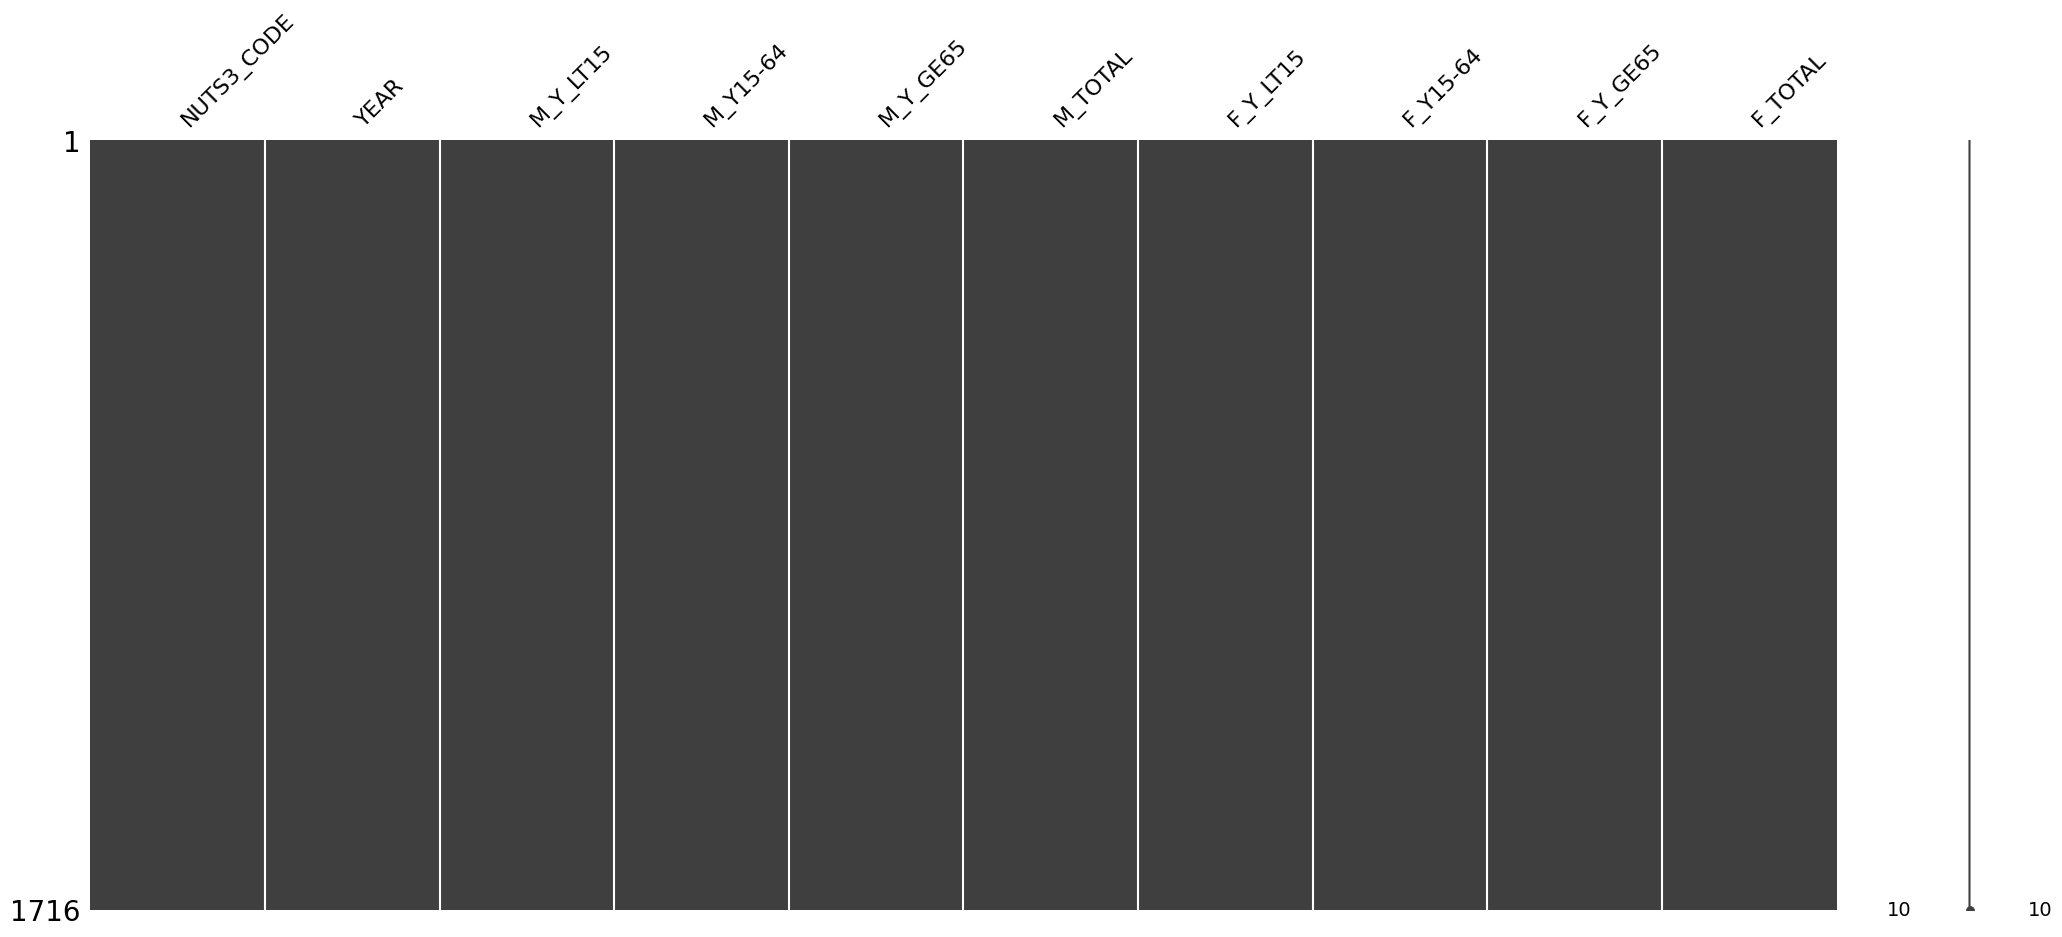

In [30]:
missingno.matrix(df_out)

In [31]:
df_out.to_csv('../data/GR_EUROSTAT_Demographics_Processed.csv', index=False)